In [1]:
import pandas as pd
import numpy as np
import nrrd
import matplotlib.pyplot as plt
import os

from pathlib import Path

current = Path().resolve()

while not (current / ".git").exists():
    current = current.parent

PROJECT_ROOT = current

output_folder = PROJECT_ROOT / "extension/"

In [2]:
file = output_folder / 'data/brain__with_unassigned_regions_m_types_composition.csv'
m_data_df = pd.read_csv(file, index_col=0)
# Combine the two levels of the MultiIndex into one
# me_data_df.columns = [f"{col[0]}|{col[1]}" for col in me_data_df.columns]

m_data_df.shape

(719, 60)

In [3]:
m_data_df

,IN_DEND_0_AX_0,IN_DEND_0_AX_3,IN_DEND_0_AX_4,IN_DEND_0_AX_5,IN_DEND_0_AX_6,IN_DEND_0_AX_8,IN_DEND_0_AX_9,IN_DEND_1_AX_0,IN_DEND_1_AX_2,IN_DEND_1_AX_3,...,PC_DEND_1_AX_7,PC_DEND_2_AX_4,PC_DEND_2_AX_8,PC_DEND_3_AX_0,PC_DEND_3_AX_4,PC_DEND_3_AX_6,PC_DEND_3_AX_7,PC_DEND_3_AX_8,PC_DEND_8_AX_4,PC_DEND_8_AX_8
AAA,479.621397,4609.089541,630.534320,285.945746,759.888528,300.217012,2136.814396,728.504683,529.549193,479.621397,...,2880.993266,0.577443,0.577443,0.288721,1247.003294,0.288721,2674.109207,2485.633670,115.255872,730.926728
ACAd1,3.758988,128.365576,542.558577,303.743935,50.334100,295.192491,14.067729,118.855819,245.396891,3.758988,...,947.632402,2.478969,2.478969,1.239485,572.863944,1.239485,947.632402,378.486912,1359.080693,1502.383317
ACAd23,41.110065,218.811773,2132.266031,388.642095,262.099774,2057.311353,133.205945,782.690621,1522.242010,41.110065,...,8713.327535,0.000000,0.000000,0.000000,4004.031908,0.000000,8713.327535,4763.516294,11000.583267,13245.602119
ACAd5,118.762991,505.568164,529.369527,549.423987,371.717769,629.176107,392.464042,650.782667,1108.484847,118.762991,...,6165.416213,0.000000,0.000000,0.000000,1096.330538,0.000000,3379.857903,2092.196462,1499.288502,3849.855852
ACAd6a,73.788733,1373.237607,1483.025603,228.520065,120.123704,1415.516425,230.865938,1407.490895,2717.607076,73.788733,...,7923.591979,0.000000,0.000000,0.000000,2337.531297,0.000000,6185.171208,3711.677663,8096.030911,9467.009209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vVIIIn,71.648815,307.171110,103.138600,96.745437,29.227897,44.075277,313.950039,99.290368,125.647694,71.648815,...,159.351412,0.000000,0.000000,0.000000,155.743086,0.000000,155.743086,311.486172,0.000000,0.000000
vhc,386.441007,4024.225278,51.544180,8304.099870,5546.871658,380.799470,1630.807556,2565.850256,4467.709053,386.441007,...,1305.011468,0.000000,0.000000,0.000000,531.907920,0.000000,779.552915,1063.815840,0.000000,0.000000
vtd,296.359155,2667.232395,0.000000,0.000000,0.000000,0.000000,1333.616197,296.359155,0.000000,296.359155,...,503.980030,0.000000,0.000000,0.000000,503.980030,0.000000,503.980030,1007.960060,0.000000,0.000000
x,286.109606,2540.106703,24.987140,20.822617,0.000000,9.370178,1287.493225,292.058925,32.811386,286.109606,...,881.711463,0.000000,0.000000,0.000000,881.711463,0.000000,881.711463,1763.422927,0.000000,0.000000


# CORTEX

VISp1, VISp4, VISp5, VISp6a, VISp6b

SSs1, SSs23, SSs4, SSs5, SSs6a, SSs6b

AUDd1, AUDd4, AUDd5, AUDd6a, AUDd6b

MOp1, MOp23, MOp5, MOp6a, MOp6b

ACAd1, ACAd23, ACAd5, ACAd6a, ACAd6b

ORBl1, ORBl23, ORBl5, ORBl6a, ORBl6b

ILA1, ILA23, ILA5, ILA6a, ILA6b

PL1, PL23, PL5, PL6a, PL6b

## Morpho types

Abbreviation Meaning	Notes

- IN: interneuron (inhibitory)
- PC: Pyramidal cell (excitatory)
- _DEND: dendrite type 0-9
- _AX: Axon type 0-9

In [4]:
m_data_df.T[['VISp1', 'VISp23', 'VISp4', 'VISp5', 'VISp6a', 'VISp6b']]

,VISp1,VISp23,VISp4,VISp5,VISp6a,VISp6b
IN_DEND_0_AX_0,1.264181,10.164981,54.545235,79.793545,49.557952,64.076942
IN_DEND_0_AX_3,71.051480,110.907905,519.645420,857.172188,404.860005,897.275301
IN_DEND_0_AX_4,346.358218,2603.554798,3323.239872,707.588916,2177.237079,2588.530175
IN_DEND_0_AX_5,177.027269,184.729732,768.463193,883.827823,280.952979,161.944357
IN_DEND_0_AX_6,16.647307,123.672558,922.475642,726.913896,168.643982,75.743256
IN_DEND_0_AX_8,208.576443,2461.247643,2996.664617,1180.442639,2309.186307,2773.423424
IN_DEND_0_AX_9,5.204153,33.846754,172.240988,259.185030,171.625344,202.031510
IN_DEND_1_AX_0,70.984520,180.986363,420.822564,588.549686,1570.569295,2070.722201
IN_DEND_1_AX_2,145.700037,349.956367,746.097161,1052.298305,3052.677603,4034.511116
IN_DEND_1_AX_3,1.264181,10.164981,54.545235,79.793545,49.557952,64.076942


In [5]:
m_data_df.columns

Index(['IN_DEND_0_AX_0', 'IN_DEND_0_AX_3', 'IN_DEND_0_AX_4', 'IN_DEND_0_AX_5',
       'IN_DEND_0_AX_6', 'IN_DEND_0_AX_8', 'IN_DEND_0_AX_9', 'IN_DEND_1_AX_0',
       'IN_DEND_1_AX_2', 'IN_DEND_1_AX_3', 'IN_DEND_1_AX_4', 'IN_DEND_1_AX_5',
       'IN_DEND_1_AX_7', 'IN_DEND_1_AX_8', 'IN_DEND_1_AX_9', 'IN_DEND_2_AX_2',
       'IN_DEND_2_AX_3', 'IN_DEND_3_AX_2', 'IN_DEND_3_AX_3', 'IN_DEND_3_AX_5',
       'IN_DEND_3_AX_7', 'IN_DEND_4_AX_2', 'IN_DEND_4_AX_3', 'IN_DEND_4_AX_5',
       'IN_DEND_4_AX_6', 'IN_DEND_4_AX_8', 'IN_DEND_4_AX_9', 'IN_DEND_5_AX_0',
       'IN_DEND_5_AX_3', 'IN_DEND_5_AX_4', 'IN_DEND_5_AX_5', 'IN_DEND_5_AX_6',
       'IN_DEND_5_AX_7', 'IN_DEND_5_AX_8', 'IN_DEND_5_AX_9', 'IN_DEND_6_AX_0',
       'IN_DEND_6_AX_3', 'IN_DEND_6_AX_8', 'IN_DEND_6_AX_9', 'IN_DEND_7_AX_0',
       'IN_DEND_7_AX_2', 'IN_DEND_7_AX_3', 'IN_DEND_7_AX_8', 'IN_DEND_8_AX_8',
       'IN_DEND_8_AX_9', 'IN_DEND_9_AX_1', 'IN_DEND_9_AX_2', 'IN_DEND_9_AX_5',
       'IN_DEND_9_AX_8', 'PC_DEND_0_AX_8', 'PC_DEND_

In [6]:
# Define neuron type groups
excitatory = m_data_df.columns[m_data_df.columns.str.startswith("PC_DEND_")].tolist()
inhibitory = m_data_df.columns[m_data_df.columns.str.startswith("IN_DEND_")].tolist()

laminar_order = ["VISp1","VISp23","VISp4","VISp5","VISp6a","VISp6b"]
df = m_data_df.T[laminar_order]
df.sum()

VISp1       8017.336574
VISp23     92635.649731
VISp4     111576.902052
VISp5      58375.880933
VISp6a     87228.480500
VISp6b    103372.481554
dtype: float64

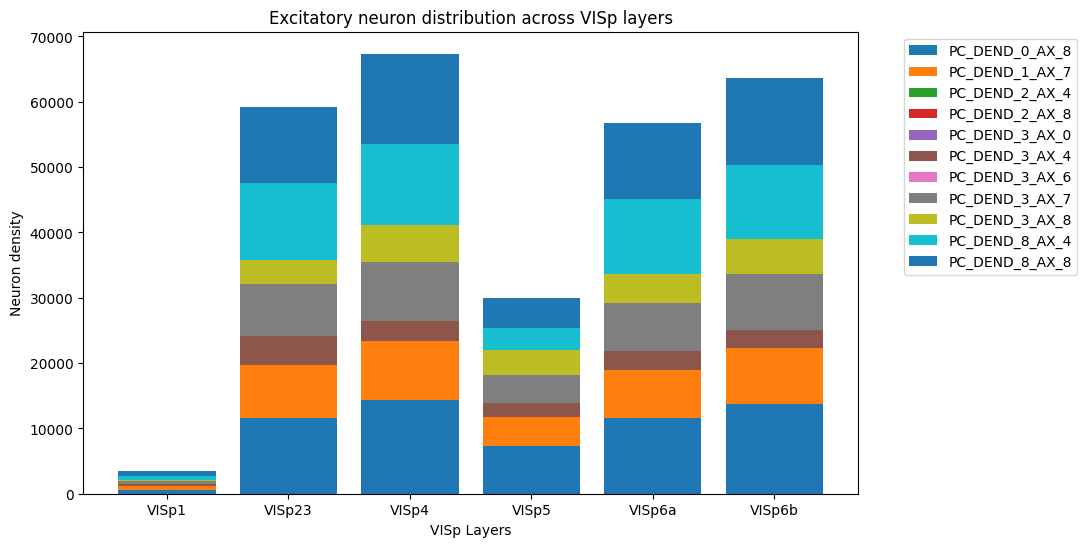

In [7]:
# Set up figure
plt.figure(figsize=(10,6))

# Plot excitatory neurons stacked
bottoms = [0]*len(laminar_order)
for neuron in excitatory:
    plt.bar(laminar_order, df.loc[neuron], bottom=bottoms, label=neuron)
    bottoms = [sum(x) for x in zip(bottoms, df.loc[neuron])]

plt.xlabel("VISp Layers")
plt.ylabel("Neuron density")
plt.title("Excitatory neuron distribution across VISp layers")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

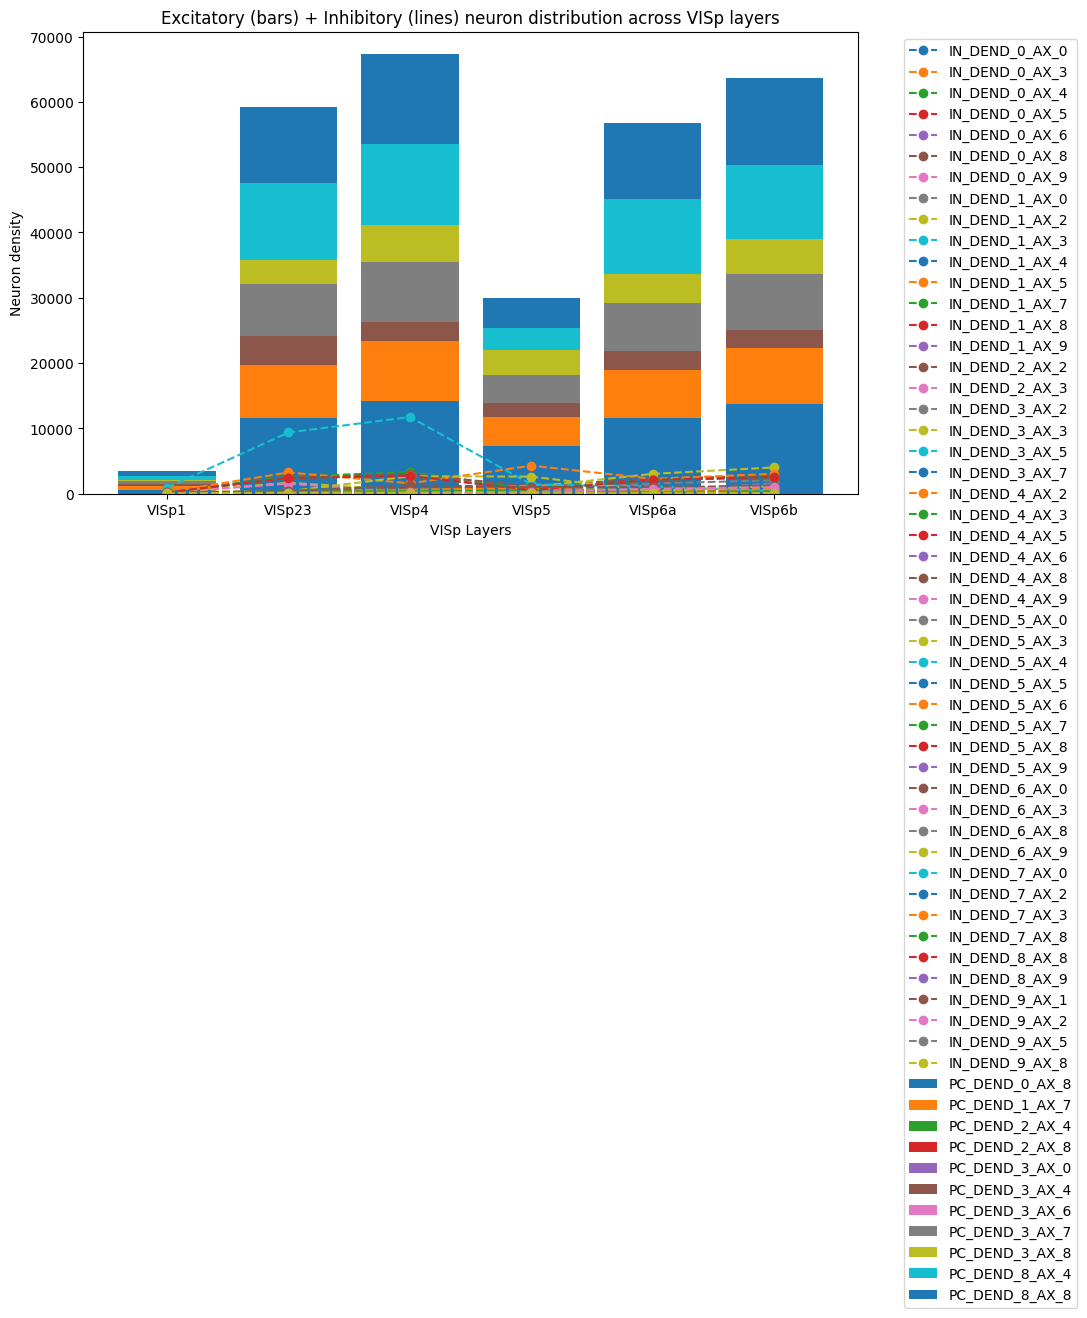

In [8]:
plt.figure(figsize=(10,6))

# Plot excitatory stacked bars first
bottoms = [0]*len(laminar_order)
for neuron in excitatory:
    plt.bar(laminar_order, df.loc[neuron], bottom=bottoms, label=neuron)
    bottoms = [sum(x) for x in zip(bottoms, df.loc[neuron])]

# Plot inhibitory neurons as line plots
for neuron in inhibitory:
    plt.plot(laminar_order, df.loc[neuron], marker='o', linestyle='--', label=neuron)

plt.xlabel("VISp Layers")
plt.ylabel("Neuron density")
plt.title("Excitatory (bars) + Inhibitory (lines) neuron distribution across VISp layers")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [9]:
[col for col in m_data_df.T.columns if col.startswith("SSs")]


['SSs1', 'SSs23', 'SSs4', 'SSs5', 'SSs6a', 'SSs6b']

In [10]:
laminar_order = ["SSs1", "SSs23", "SSs4", "SSs5", "SSs6a", "SSs6b"]
df = m_data_df.T[laminar_order]
df.sum()

SSs1      8949.646279
SSs23    80159.732507
SSs4     74507.182660
SSs5     34959.216184
SSs6a    66261.415550
SSs6b    72102.545676
dtype: float64

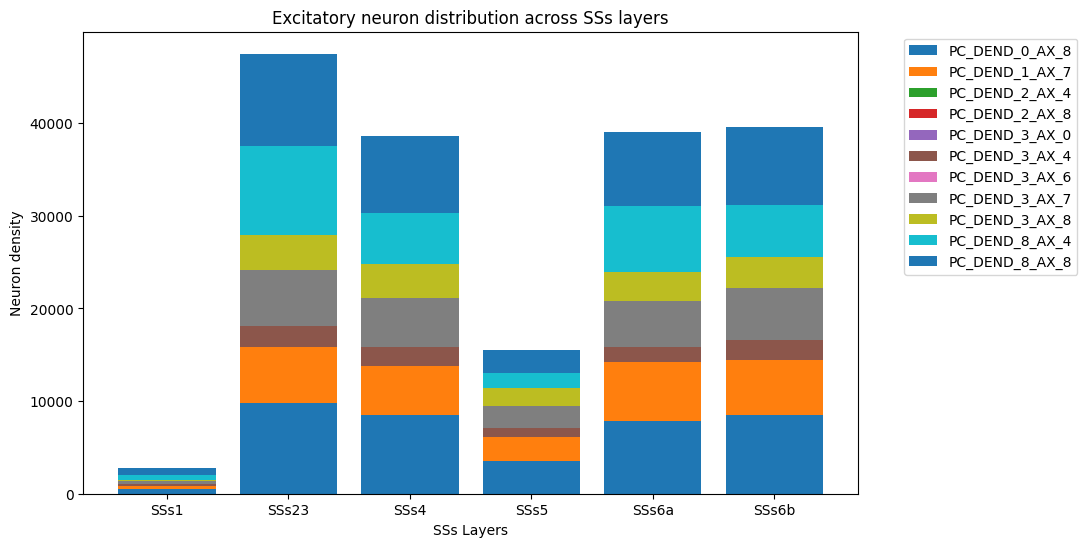

In [11]:
# Set up figure
plt.figure(figsize=(10,6))

# Plot excitatory neurons stacked
bottoms = [0]*len(laminar_order)
for neuron in excitatory:
    plt.bar(laminar_order, df.loc[neuron], bottom=bottoms, label=neuron)
    bottoms = [sum(x) for x in zip(bottoms, df.loc[neuron])]

plt.xlabel("SSs Layers")
plt.ylabel("Neuron density")
plt.title("Excitatory neuron distribution across SSs layers")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

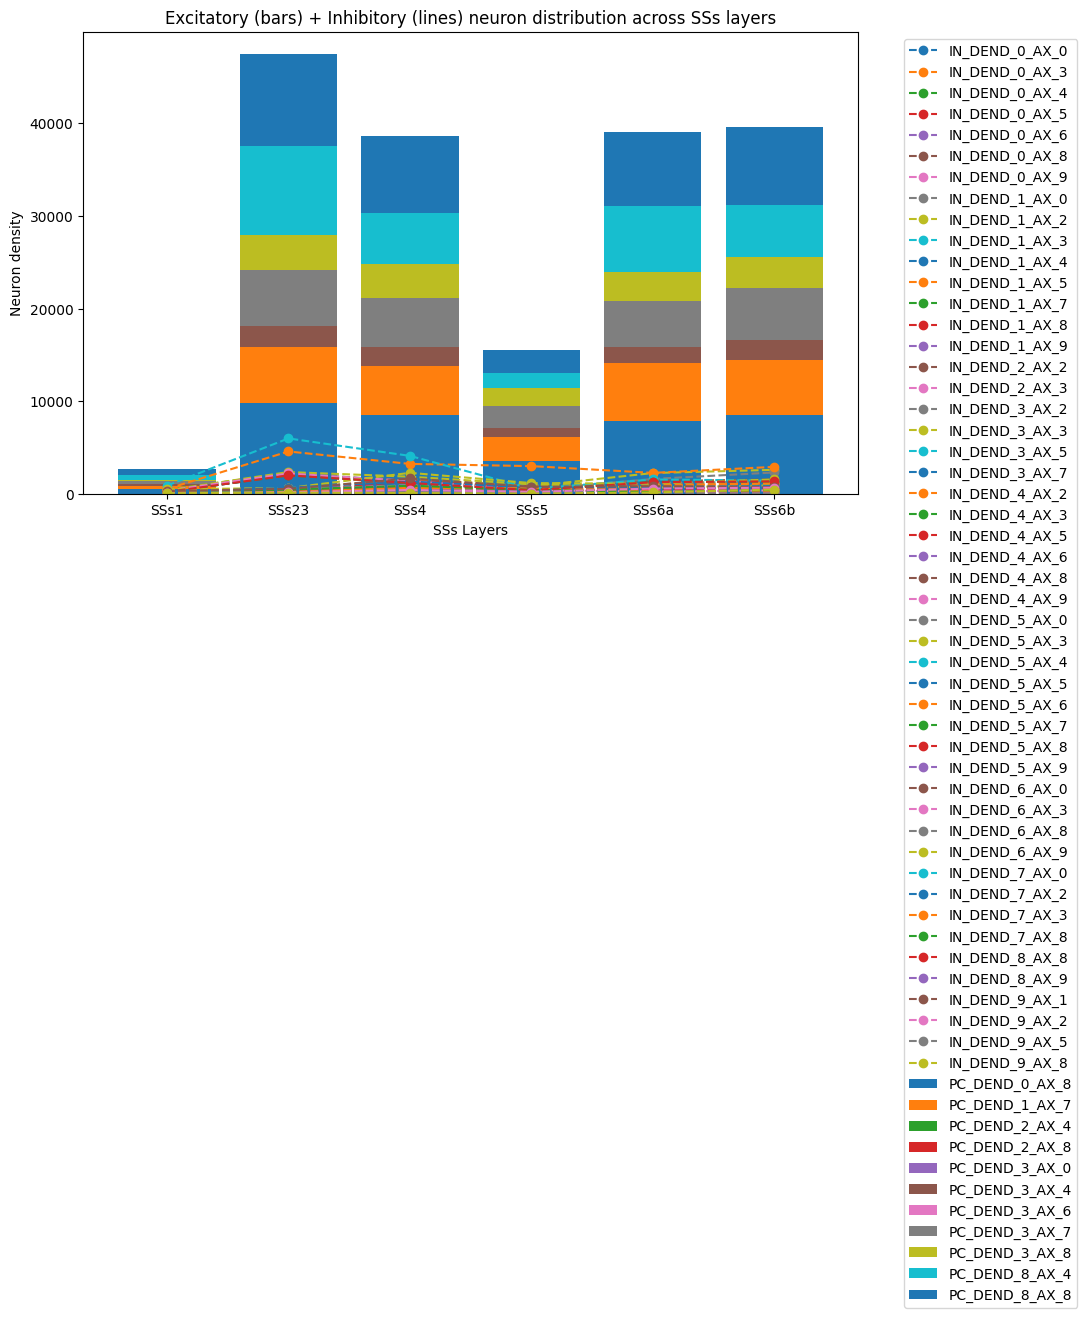

In [12]:
plt.figure(figsize=(10,6))

# Plot excitatory stacked bars first
bottoms = [0]*len(laminar_order)
for neuron in excitatory:
    plt.bar(laminar_order, df.loc[neuron], bottom=bottoms, label=neuron)
    bottoms = [sum(x) for x in zip(bottoms, df.loc[neuron])]

# Plot inhibitory neurons as line plots
for neuron in inhibitory:
    plt.plot(laminar_order, df.loc[neuron], marker='o', linestyle='--', label=neuron)

plt.xlabel("SSs Layers")
plt.ylabel("Neuron density")
plt.title("Excitatory (bars) + Inhibitory (lines) neuron distribution across SSs layers")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [13]:
[col for col in m_data_df.T.columns if col.startswith("AUD")]

['AUDd1',
 'AUDd23',
 'AUDd4',
 'AUDd5',
 'AUDd6a',
 'AUDd6b',
 'AUDp1',
 'AUDp23',
 'AUDp4',
 'AUDp5',
 'AUDp6a',
 'AUDp6b',
 'AUDpo1',
 'AUDpo23',
 'AUDpo4',
 'AUDpo5',
 'AUDpo6a',
 'AUDpo6b',
 'AUDv1',
 'AUDv23',
 'AUDv4',
 'AUDv5',
 'AUDv6a',
 'AUDv6b']

In [14]:
[col for col in m_data_df.T.columns if col.startswith("VISp")]

['VISp1',
 'VISp23',
 'VISp4',
 'VISp5',
 'VISp6a',
 'VISp6b',
 'VISpl1',
 'VISpl23',
 'VISpl4',
 'VISpl5',
 'VISpl6a',
 'VISpl6b',
 'VISpm1',
 'VISpm23',
 'VISpm4',
 'VISpm5',
 'VISpm6a',
 'VISpm6b',
 'VISpor1',
 'VISpor23',
 'VISpor4',
 'VISpor5',
 'VISpor6a',
 'VISpor6b']

In [15]:
laminar_order = ["AUDv1", "AUDv23", "AUDv4", "AUDv5", "AUDv6a", "AUDv6b"]
df = m_data_df.T[laminar_order]
df.sum()

AUDv1      8681.493408
AUDv23    80594.156421
AUDv4     86169.957231
AUDv5     41517.240026
AUDv6a    74928.758701
AUDv6b    71863.735869
dtype: float64

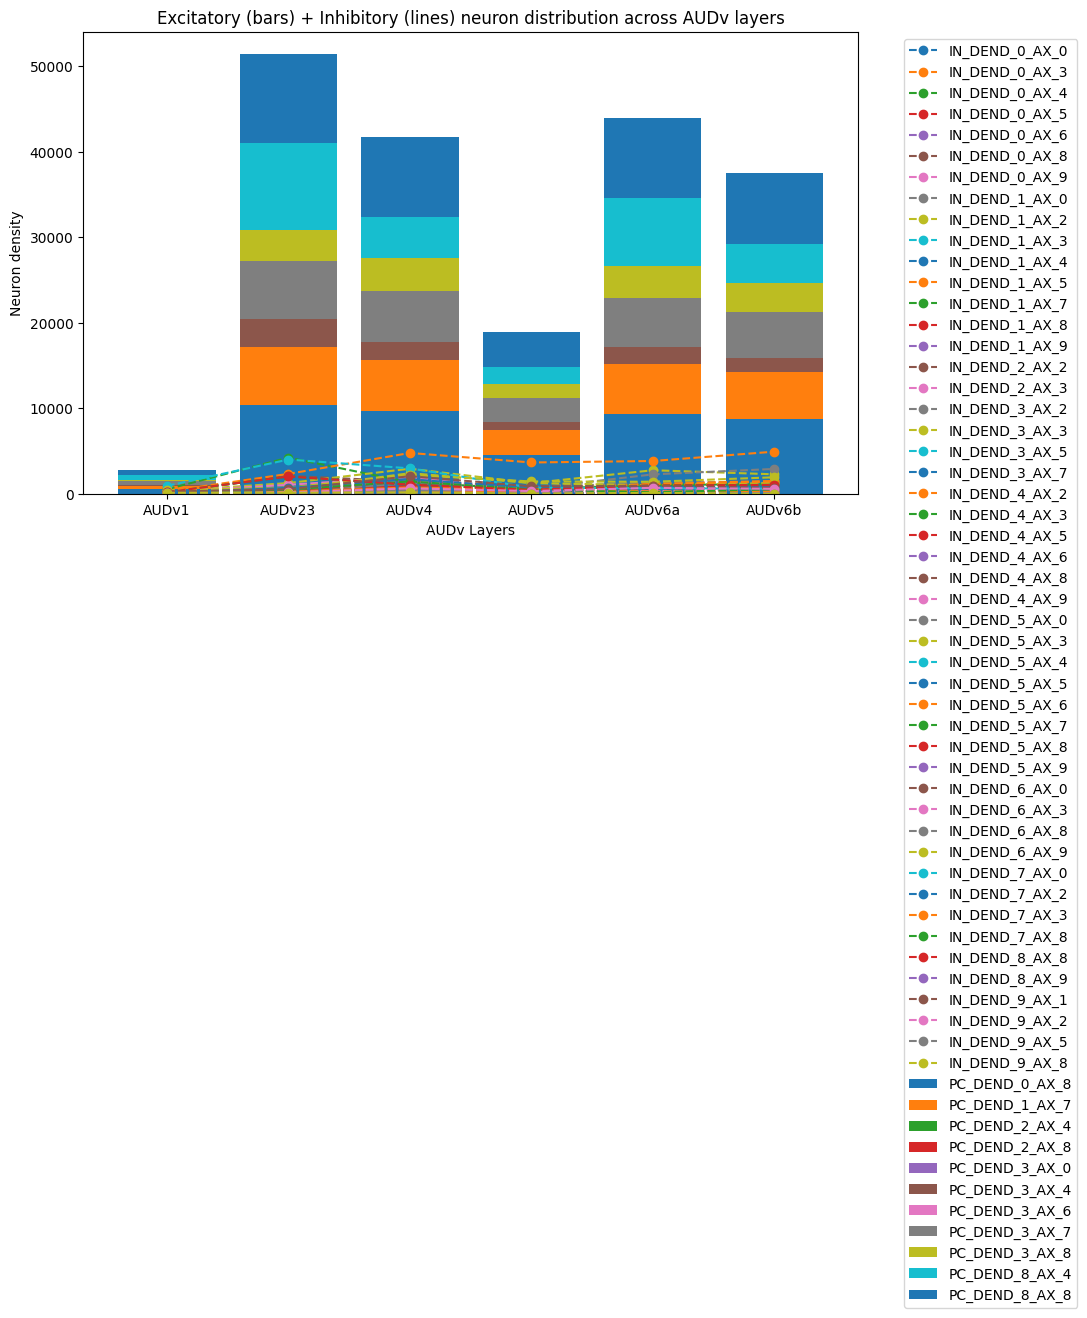

In [16]:
plt.figure(figsize=(10,6))

# Plot excitatory stacked bars first
bottoms = [0]*len(laminar_order)
for neuron in excitatory:
    plt.bar(laminar_order, df.loc[neuron], bottom=bottoms, label=neuron)
    bottoms = [sum(x) for x in zip(bottoms, df.loc[neuron])]

# Plot inhibitory neurons as line plots
for neuron in inhibitory:
    plt.plot(laminar_order, df.loc[neuron], marker='o', linestyle='--', label=neuron)

plt.xlabel("AUDv Layers")
plt.ylabel("Neuron density")
plt.title("Excitatory (bars) + Inhibitory (lines) neuron distribution across AUDv layers")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [17]:
laminar_order = [col for col in m_data_df.T.columns if col.startswith("ILA")]
df = m_data_df.T[laminar_order]
df.sum()

ILA1      33181.963216
ILA23    118641.418519
ILA5      48858.212837
ILA6a    109312.085503
ILA6b     89407.049287
dtype: float64

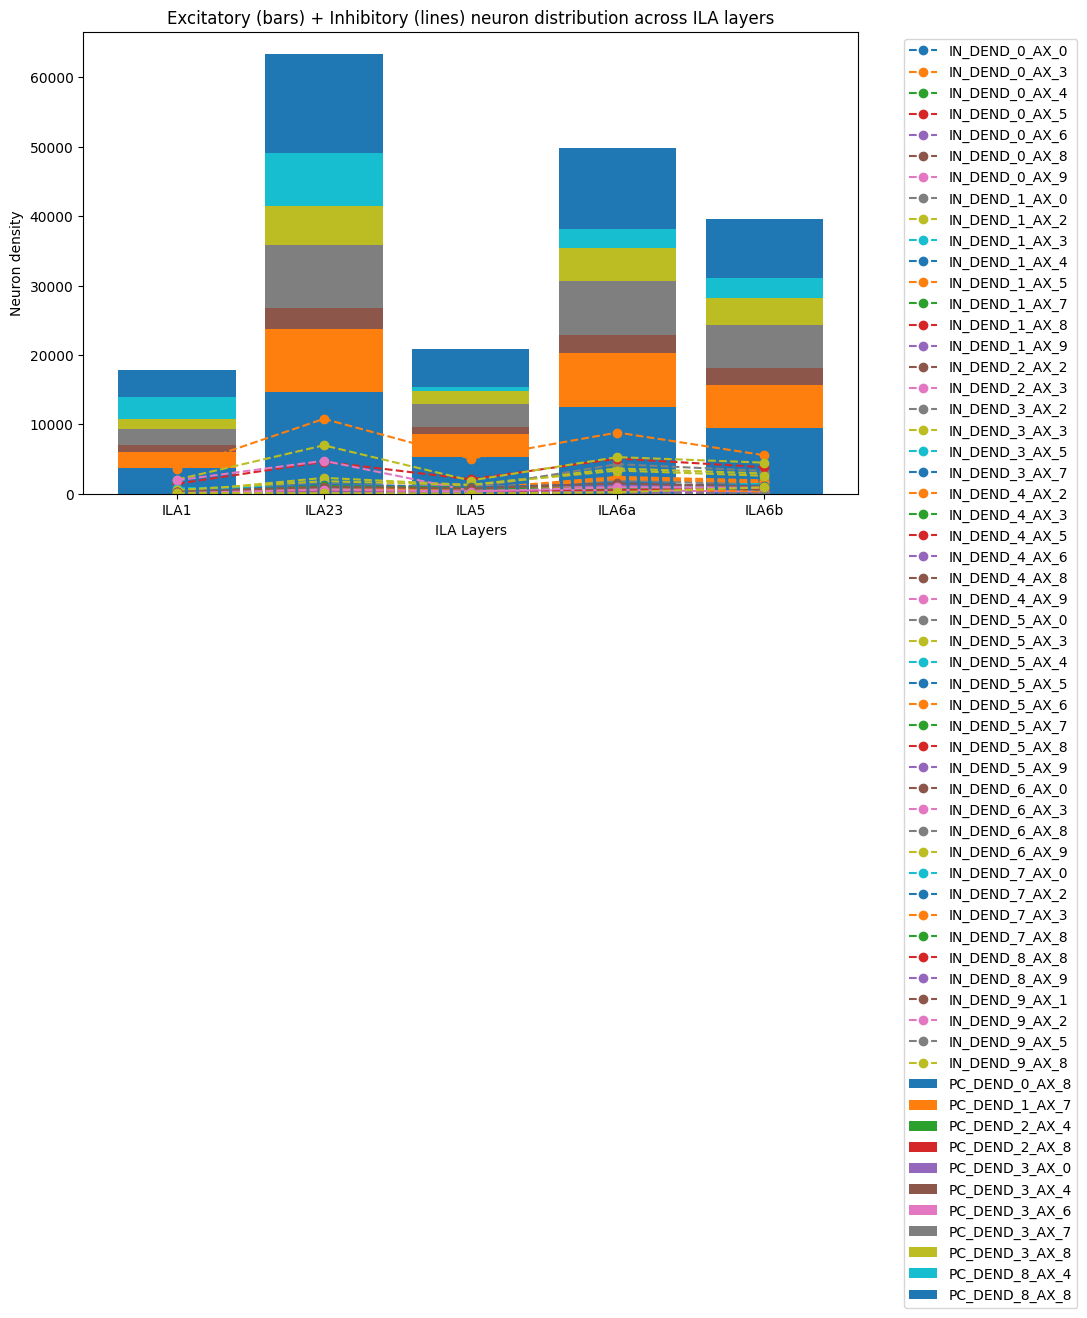

In [18]:
plt.figure(figsize=(10,6))

# Plot excitatory stacked bars first
bottoms = [0]*len(laminar_order)
for neuron in excitatory:
    plt.bar(laminar_order, df.loc[neuron], bottom=bottoms, label=neuron)
    bottoms = [sum(x) for x in zip(bottoms, df.loc[neuron])]

# Plot inhibitory neurons as line plots
for neuron in inhibitory:
    plt.plot(laminar_order, df.loc[neuron], marker='o', linestyle='--', label=neuron)

plt.xlabel("ILA Layers")
plt.ylabel("Neuron density")
plt.title("Excitatory (bars) + Inhibitory (lines) neuron distribution across ILA layers")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Collapse M-TYPES

## AXONAL TYPES

- IN_DEND_<X>_AX_<Y>  →  IN_DEND_AX_<Y>
- PC_DEND_<X>_AX_<Y>  →  PC_DEND_AX_<Y>

In [19]:
import re

# Select only dend columns
dend_cols = [c for c in m_data_df.columns if "_DEND_" in c]

# Create mapping: original column → collapsed column name
col_map = {}

for col in dend_cols:
    match = re.match(r"(IN|PC)_DEND_\d+_AX_(\d+)", col)
    if match:
        cell_type = match.group(1)   # IN or PC
        ax_id = match.group(2)       # 0–9
        new_name = f"{cell_type}_DEND_AX_{ax_id}"
        col_map[col] = new_name

# Rename temporarily
temp_df = m_data_df[dend_cols].rename(columns=col_map)

# Group by new column names and sum
collapsed_df = temp_df.groupby(level=0, axis=1).sum()

/tmp/ipykernel_5421/2621074459.py:21: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  collapsed_df = temp_df.groupby(level=0, axis=1).sum()


In [20]:
collapsed_df.columns

Index(['IN_DEND_AX_0', 'IN_DEND_AX_1', 'IN_DEND_AX_2', 'IN_DEND_AX_3',
       'IN_DEND_AX_4', 'IN_DEND_AX_5', 'IN_DEND_AX_6', 'IN_DEND_AX_7',
       'IN_DEND_AX_8', 'IN_DEND_AX_9', 'PC_DEND_AX_0', 'PC_DEND_AX_4',
       'PC_DEND_AX_6', 'PC_DEND_AX_7', 'PC_DEND_AX_8'],
      dtype='object')

In [21]:
collapsed_df

,IN_DEND_AX_0,IN_DEND_AX_1,IN_DEND_AX_2,IN_DEND_AX_3,IN_DEND_AX_4,IN_DEND_AX_5,IN_DEND_AX_6,IN_DEND_AX_7,IN_DEND_AX_8,IN_DEND_AX_9,PC_DEND_AX_0,PC_DEND_AX_4,PC_DEND_AX_6,PC_DEND_AX_7,PC_DEND_AX_8
AAA,9065.568186,303.047509,12135.542516,17420.995460,1013.965923,11928.836499,3463.742183,432.372773,5504.390919,14142.940386,0.288721,1362.836609,0.288721,5555.102473,4517.231085
ACAd1,205.521562,341.013917,1793.873308,1808.903690,1777.897273,681.551291,153.236516,602.157714,1080.946547,861.320667,1.239485,1934.423607,1.239485,1895.264805,3205.750059
ACAd23,1345.345677,887.537692,11045.571302,8196.777550,7686.580441,2175.902170,554.715626,4281.952094,6868.812781,3597.441256,0.000000,15004.615175,0.000000,17426.655071,31467.084065
ACAd5,2119.169519,677.718078,8338.700026,5124.713357,1166.172223,2604.404645,743.722132,1012.487363,3507.946496,3768.728324,0.000000,2595.619040,0.000000,9545.274116,11505.796535
ACAd6a,1876.438147,928.975877,11106.457350,3308.622887,2832.814685,2497.635292,1423.028655,3261.592549,4829.843693,3289.341471,0.000000,10433.562208,0.000000,14108.763187,22661.510407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vVIIIn,1280.715401,99.467590,1380.321237,1916.378163,288.857043,1773.164411,390.130001,82.579843,1209.373026,1698.022518,0.000000,155.743086,0.000000,315.094498,320.506987
vhc,13438.953715,1131.166702,29811.931879,34540.215955,1168.471443,29899.100128,9703.464280,1116.927263,11684.394641,24819.693921,0.000000,531.907920,0.000000,2084.564383,1231.171882
vtd,5334.464790,0.000000,5221.714074,8904.945747,0.000000,6891.085246,1333.616197,0.000000,3225.991629,7052.623770,0.000000,503.980030,0.000000,1007.960060,1007.960060
x,5155.922220,22.309947,5491.861744,8647.205575,69.607033,6086.470276,1267.297317,19.632753,1655.225366,6695.501906,0.000000,881.711463,0.000000,1763.422927,1763.422927


In [22]:
excitatory = collapsed_df.columns[collapsed_df.columns.str.startswith("PC_DEND_")].tolist()
inhibitory = collapsed_df.columns[collapsed_df.columns.str.startswith("IN_DEND_")].tolist()

laminar_order = ["VISp1","VISp23","VISp4","VISp5","VISp6a","VISp6b"]
df = collapsed_df.T[laminar_order]

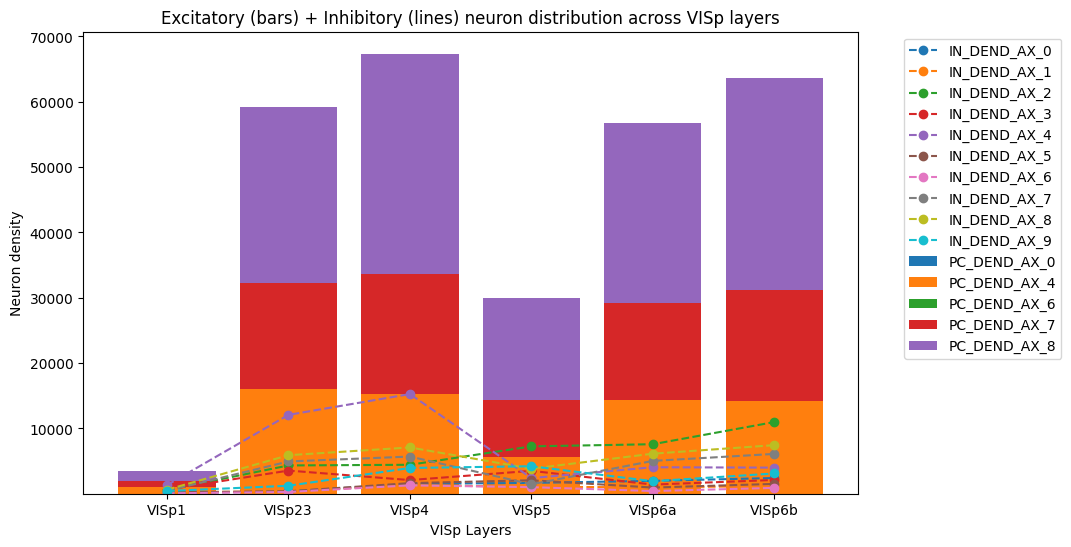

In [23]:
plt.figure(figsize=(10,6))

# Plot excitatory stacked bars first
bottoms = [0]*len(laminar_order)
for neuron in excitatory:
    plt.bar(laminar_order, df.loc[neuron], bottom=bottoms, label=neuron)
    bottoms = [sum(x) for x in zip(bottoms, df.loc[neuron])]

# Plot inhibitory neurons as line plots
for neuron in inhibitory:
    plt.plot(laminar_order, df.loc[neuron], marker='o', linestyle='--', label=neuron)

plt.xlabel("VISp Layers")
plt.ylabel("Neuron density")
plt.title("Excitatory (bars) + Inhibitory (lines) neuron distribution across VISp layers")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Dendiritic types

- IN_DEND_<dend>_AX_<ax>  →  IN_DEND_<dend>
- PC_DEND_<dend>_AX_<ax>  →  PC_DEND_<dend>

In [24]:
import re

dend_cols = [c for c in m_data_df.columns if "_DEND_" in c]

col_map = {}

for col in dend_cols:
    match = re.match(r"(IN|PC)_DEND_(\d+)_AX_\d+", col)
    if match:
        cell_type = match.group(1)   # IN or PC
        dend_id = match.group(2)    # dend cluster index
        new_name = f"{cell_type}_DEND_{dend_id}"
        col_map[col] = new_name

temp_df = m_data_df[dend_cols].rename(columns=col_map)

collapsed_df = temp_df.groupby(level=0, axis=1).sum()

/tmp/ipykernel_5421/392979907.py:17: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  collapsed_df = temp_df.groupby(level=0, axis=1).sum()


In [25]:
excitatory = collapsed_df.columns[collapsed_df.columns.str.startswith("PC_DEND_")].tolist()
inhibitory = collapsed_df.columns[collapsed_df.columns.str.startswith("IN_DEND_")].tolist()

laminar_order = ["VISp1","VISp23","VISp4","VISp5","VISp6a","VISp6b"]
df = collapsed_df.T[laminar_order]

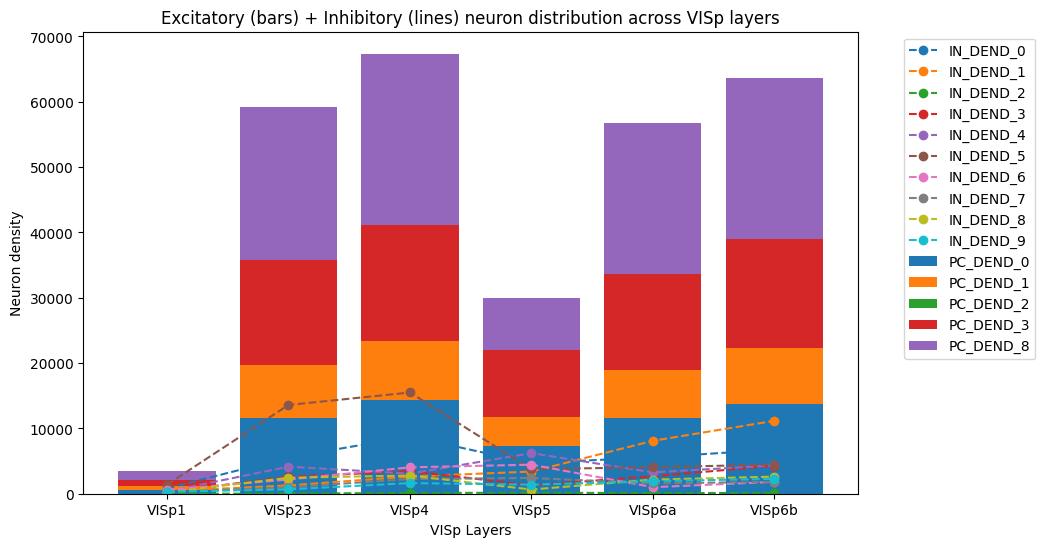

In [26]:
plt.figure(figsize=(10,6))

# Plot excitatory stacked bars first
bottoms = [0]*len(laminar_order)
for neuron in excitatory:
    plt.bar(laminar_order, df.loc[neuron], bottom=bottoms, label=neuron)
    bottoms = [sum(x) for x in zip(bottoms, df.loc[neuron])]

# Plot inhibitory neurons as line plots
for neuron in inhibitory:
    plt.plot(laminar_order, df.loc[neuron], marker='o', linestyle='--', label=neuron)

plt.xlabel("VISp Layers")
plt.ylabel("Neuron density")
plt.title("Excitatory (bars) + Inhibitory (lines) neuron distribution across VISp layers")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [27]:
[col for col in collapsed_df.columns if col.startswith("VISp")]

[]